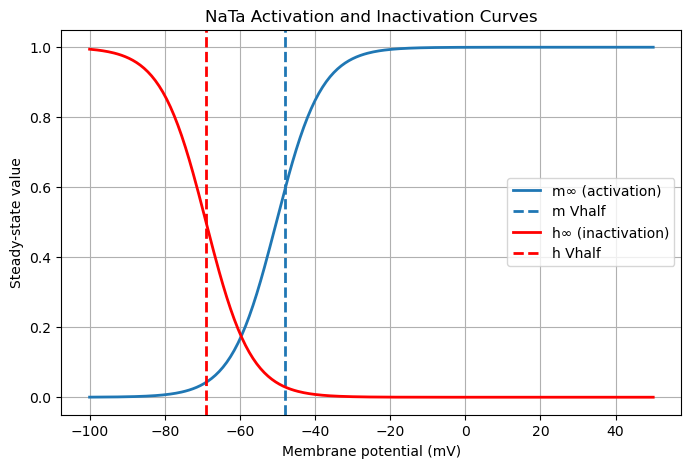

In [12]:
# Cell 1: import libraries
import numpy as np
import matplotlib.pyplot as plt

# Cell 2: define NaTa parameters from the MOD file
malphaF = 0.182
mbetaF  = 0.124
mvhalf  = -48.0   # mV
mk      = 6.0     # mV

halphaF = 0.015
hbetaF  = 0.015
hvhalf  = -69.0   # mV
hk      = 6.0     # mV

# Cell 3: define the vtrap helper function
def vtrap(x, y):
    """
    Helper function for rate equations to handle small x/y values.
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        small = np.abs(x / y) < 1e-6
        result = np.empty_like(x)
        result[small] = y * (1 - x[small] / y / 2)
        result[~small] = x[~small] / (np.exp(x[~small] / y) - 1)
    return result

# Cell 4: compute mInf and hInf over a voltage range
V = np.linspace(-100, 50, 301)   # -100 mV to +50 mV

# Compute activation (m)
mAlpha = malphaF * vtrap(-(V - mvhalf), mk)
mBeta  = mbetaF  * vtrap((V - mvhalf), mk)
mInf   = mAlpha / (mAlpha + mBeta)

# Compute inactivation (h)
hAlpha = halphaF * vtrap(V - hvhalf, hk)
hBeta  = hbetaF  * vtrap(-(V - hvhalf), hk)
hInf   = hAlpha / (hAlpha + hBeta)

# Cell 5: plot the results
plt.figure(figsize=(8, 5))
plt.plot(V, mInf, label='m∞ (activation)', linewidth=2)
plt.axvline(mvhalf, label='m Vhalf', linestyle='--', linewidth=2 )
plt.plot(V, hInf, label='h∞ (inactivation)', linewidth=2,color='red')
plt.axvline(hvhalf, label='h Vhalf', linestyle='--', linewidth=2, color='red')
plt.xlabel('Membrane potential (mV)')
plt.ylabel('Steady-state value')
plt.title('NaTa Activation and Inactivation Curves')
plt.legend()
plt.grid(True)
plt.ylim(-0.05, 1.05)
plt.show()


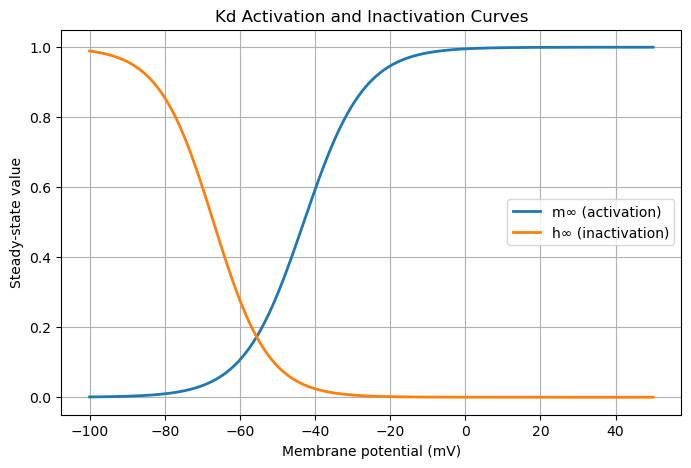

In [2]:
# Cell 1: import libraries
import numpy as np
import matplotlib.pyplot as plt

# Cell 2: define Kd steady‐state parameters from the MOD file
# Activation (mInf):
#   mInf(V) = 1 − 1 / [1 + exp((V − (−43)) / 8)]
# Inactivation (hInf):
#   hInf(V) = 1 / [1 + exp((V − (−67)) / 7.3)]

# No alpha/beta rates are needed because mInf and hInf are given explicitly.

# Cell 3: compute mInf and hInf over a voltage range
V = np.linspace(-100, 50, 301)   # –100 mV to +50 mV

mInf = 1 - 1 / (1 + np.exp((V - (-43)) / 8))
hInf = 1     / (1 + np.exp((V - (-67)) / 7.3))

# Cell 4: plot the activation (mInf) and inactivation (hInf) curves
plt.figure(figsize=(8, 5))
plt.plot(V, mInf, label='m∞ (activation)', linewidth=2)
plt.plot(V, hInf, label='h∞ (inactivation)', linewidth=2)
plt.xlabel('Membrane potential (mV)')
plt.ylabel('Steady‐state value')
plt.title('Kd Activation and Inactivation Curves')
plt.legend()
plt.grid(True)
plt.ylim(-0.05, 1.05)
plt.show()
